<a href="https://colab.research.google.com/github/NikethnaSri-AI/Aanseaa_Technologies_Internship/blob/main/transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from keras.utils import plot_model
from tensorflow.keras import models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img, load_img
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_dir = '/content/drive/My Drive/brain_tumor_classification/Training'
test_dir = '/content/drive/My Drive/brain_tumor_classification/Testing'
categories = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

In [ ]:
image_paths_train = []
labels_train = []

In [ ]:
for category in categories:
    category_dir = os.path.join(train_dir, category)
    for filename in os.listdir(category_dir):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            image_paths_train.append(os.path.join(category_dir, filename))
            labels_train.append(category)

In [ ]:
data = pd.DataFrame({
    'image_path': image_paths_train,
    'label': labels_train
})

print(data.head())

                                          image_path         label
0  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
1  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
2  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
3  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
4  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor


In [ ]:
train_data, val_data = train_test_split(data, test_size=0.2, stratify=data['label'])

In [ ]:
image_paths_test = []
labels_test = []
for category in categories:
    category_dir = os.path.join(test_dir, category)
    for filename in os.listdir(category_dir):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            image_paths_test.append(os.path.join(category_dir, filename))
            labels_test.append(category)
data_test = pd.DataFrame({
    'image_path': image_paths_test,
    'label': labels_test
})

print(data_test.head())

                                          image_path         label
0  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
1  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
2  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
3  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor
4  /content/drive/My Drive/brain_tumor_classifica...  glioma_tumor


In [ ]:
print(len(labels_train))
print(len(labels_test))

2870
394


In [ ]:
print(f"Training images: {len(train_data)}")
print(f"Validation images: {len(val_data)}")
print(f"Test images: {len(data_test)}")

Training images: 2296
Validation images: 574
Test images: 394


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
image_size = (150, 150)
batch_size = 32
image_shape = (150, 150, 3)
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    x_col='image_path',
    y_col='label',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical')

validation_generator = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    x_col='image_path',
    y_col='label',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical')

test_generator = test_datagen.flow_from_dataframe(
    dataframe=data_test,
    x_col='image_path',
    y_col='label',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False)

Found 2296 validated image filenames belonging to 4 classes.
Found 574 validated image filenames belonging to 4 classes.
Found 394 validated image filenames belonging to 4 classes.


In [ ]:
vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=image_shape)

In [ ]:
for layer in vgg16.layers:
    layer.trainable = False
x = vgg16.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(len(categories), activation='softmax')(x)
model = Model(inputs=vgg16.input, outputs=predictions)
model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0   

In [ ]:
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(factor=0.5, patience=5)
checkpoint = ModelCheckpoint('best_vgg16_model.keras', save_best_only=True)

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    callbacks=[early_stopping, reduce_lr, checkpoint]
)

Epoch 1/10
71/71 [==============================] - 703s 10s/step - loss: 1.2447 - accuracy: 0.4426 - val_loss: 0.8799 - val_accuracy: 0.6673 - lr: 0.0010
Epoch 2/10
71/71 [==============================] - 676s 10s/step - loss: 0.8296 - accuracy: 0.6533 - val_loss: 0.6304 - val_accuracy: 0.7629 - lr: 0.0010
Epoch 3/10
71/71 [==============================] - 679s 10s/step - loss: 0.6520 - accuracy: 0.7438 - val_loss: 0.5258 - val_accuracy: 0.7904 - lr: 0.0010
Epoch 4/10
71/71 [==============================] - 663s 9s/step - loss: 0.6000 - accuracy: 0.7690 - val_loss: 0.5106 - val_accuracy: 0.7886 - lr: 0.0010
Epoch 5/10
71/71 [==============================] - 678s 10s/step - loss: 0.5389 - accuracy: 0.7933 - val_loss: 0.4749 - val_accuracy: 0.8107 - lr: 0.0010
Epoch 6/10
71/71 [==============================] - 677s 10s/step - loss: 0.5097 - accuracy: 0.8052 - val_loss: 0.4361 - val_accuracy: 0.8272 - lr: 0.0010
Epoch 7/10
71/71 [==============================] - 679s 10s/step - los

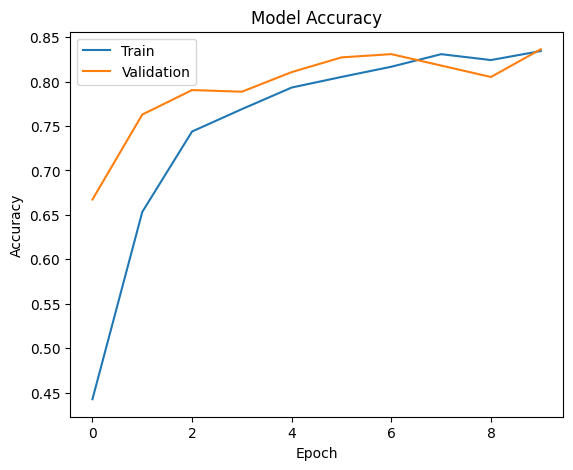

In [ ]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')


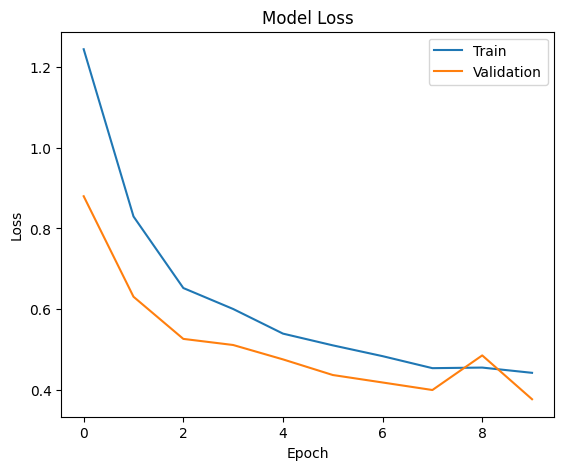

In [ ]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

In [ ]:
loss, accuracy = model.evaluate(test_generator, steps=test_generator.samples // batch_size)
print(f"Test Loss: {loss:0.5f}")
print(f"Test Accuracy: {accuracy:0.5f}")

12/12 [==============================] - 93s 7s/step - loss: 1.5767 - accuracy: 0.5599
Test Loss: 1.57675
Test Accuracy: 0.55990


13/13 [==============================] - 93s 7s/step


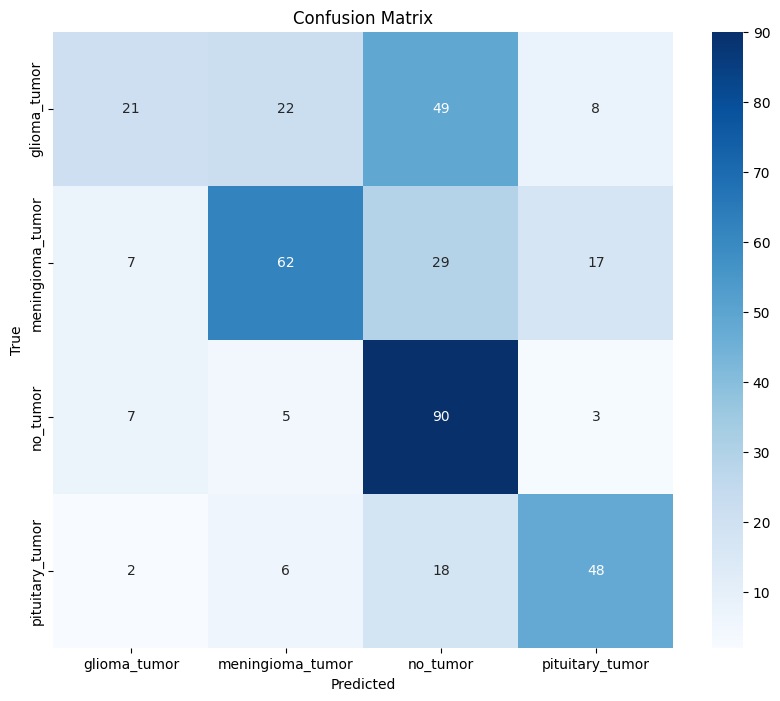

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
test_generator.reset()

predictions = model.predict(test_generator, steps=test_generator.samples // batch_size + 1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print("Classification Report:")
print(report)

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       0.57      0.21      0.31       100
meningioma_tumor       0.65      0.54      0.59       115
        no_tumor       0.48      0.86      0.62       105
 pituitary_tumor       0.63      0.65      0.64        74

        accuracy                           0.56       394
       macro avg       0.58      0.56      0.54       394
    weighted avg       0.58      0.56      0.54       394



In [ ]:
from PIL import Image
import io
import ipywidgets as widgets
from IPython.display import display

FileUpload(value={}, accept='image/*', description='Upload')

Button(description='Predict', style=ButtonStyle())

Please upload an image first.


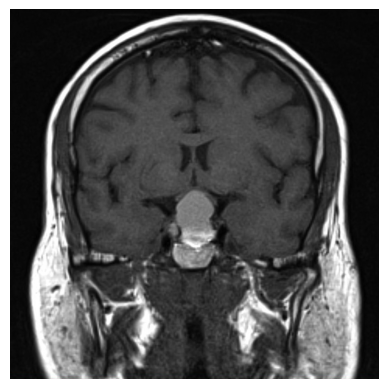

1/1 [==============================] - 0s 402ms/step
The Model predicts that it is a Pituitary Tumor


In [ ]:
from PIL import Image
import io
import ipywidgets as widgets
from IPython.display import display

def img_pred(upload):
    for name, file_info in upload.value.items():
        img = Image.open(io.BytesIO(file_info['content']))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        img = img.convert('RGB')
        img = img.resize((150, 150))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0
        prediction_scores = model.predict(img_array)
        predicted_index = np.argmax(prediction_scores, axis=1)[0]
        class_labels = list(test_generator.class_indices.keys())
        prediction = class_labels[predicted_index]
        confidence = np.max(prediction_scores) * 100
        print(f"The Model predicts that it is: {prediction}")
        print(f"Confidence: {confidence:.2f}%")

uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

display(uploader)
predict_button = widgets.Button(description="Predict")
display(predict_button)

def on_predict_button_clicked(b):
    if uploader.value:
        img_pred(uploader)
    else:
        print("Please upload an image first.")
predict_button.on_click(on_predict_button_clicked)